# Presentation · Per-outlet touching pairs

**Primary interface** for the per-outlet figure: one Mars network with every
predicted-touching pair's branches in a distinct colour. Calls
`channel_heads.viz.render_outlet_touching_pairs` — the same renderer the batch
script `scripts/rendering/render_mars_outlet_touching_pairs.py` uses.

It is **read-only**: it renders the busiest network inline and writes no PNGs.

> Uses the combined-inference predictions + topology. If absent, it stops
> gracefully.

In [1]:
import geopandas as gpd
import pandas as pd

from channel_heads.config import PROJECT_ROOT
from channel_heads.viz import render_outlet_touching_pairs

PRED = PROJECT_ROOT / "data/Mars/model_outputs/mars_combined_model_predictions.parquet"
PAIRS_GPKG = PROJECT_ROOT / "data/Mars/topology/mars_vn_pairs.gpkg"
TOPOLOGY_GPKG = PROJECT_ROOT / "data/Mars/topology/mars_vn_topology_model_ready.gpkg"
TOUCHING_COL = "pred_touching_emb"

have_data = PRED.exists() and PAIRS_GPKG.exists() and TOPOLOGY_GPKG.exists()
print("inputs present:", have_data)

inputs present: True


## Pick the busiest network + build lookups (read-only)

In [2]:
if have_data:
    df = pd.read_parquet(PRED)
    nodes_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_nodes")
    segs_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_segments")
    pair_paths = gpd.read_file(PAIRS_GPKG, layer="mars_pair_paths")
    try:
        outlets_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_outlets")
        outlets_by_nid = {int(r["network_id"]): (float(r.geometry.x), float(r.geometry.y))
                          for _, r in outlets_gdf.iterrows()}
    except Exception:
        outlets_by_nid = {}

    nodes_by_nid = dict(tuple(nodes_gdf.groupby("network_id")))
    segs_by_nid = dict(tuple(segs_gdf.groupby("network_id")))
    paths_lookup = {(str(r["pair_id"]), str(r["branch"])): r.geometry
                    for _, r in pair_paths.iterrows()}

    counts = (df.groupby("network_id")
              .agg(n_touching=(TOUCHING_COL, "sum"))
              .sort_values("n_touching", ascending=False))
    counts = counts[counts["n_touching"] > 0]
    nid = int(counts.index[0])
    print(f"busiest network: {nid} ({int(counts.iloc[0]['n_touching'])} touching pairs)")
else:
    print("inputs absent — skipping")

busiest network: 1 (53 touching pairs)


## Render the per-outlet figure inline

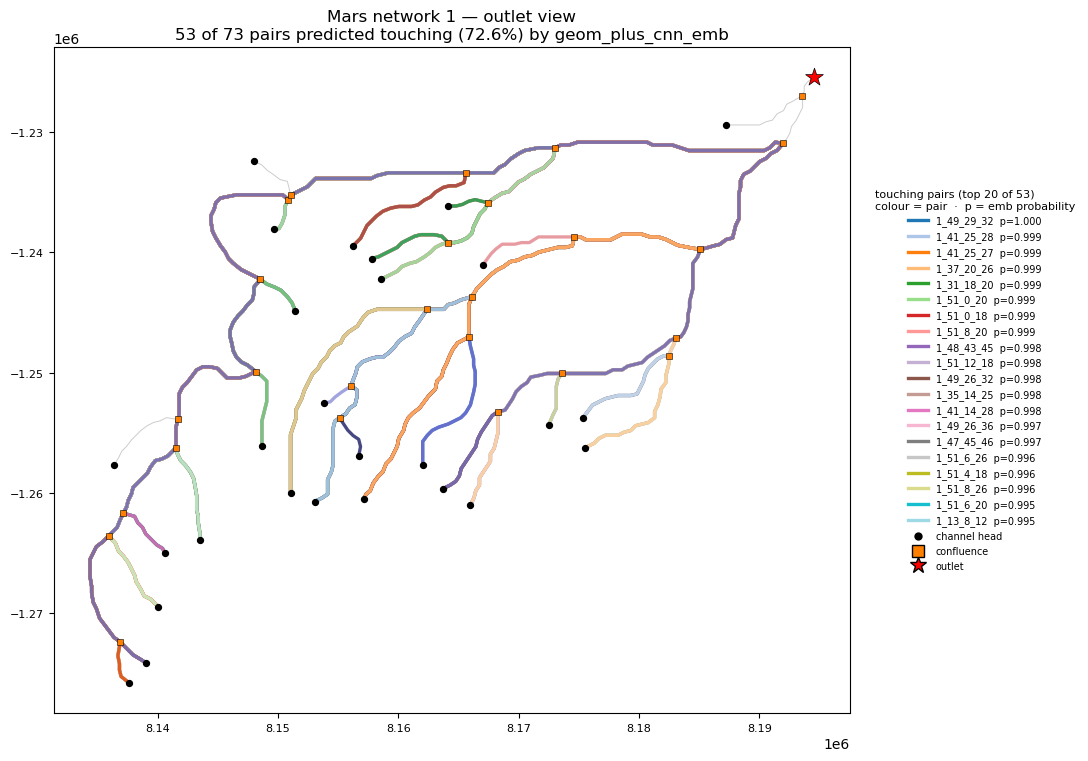

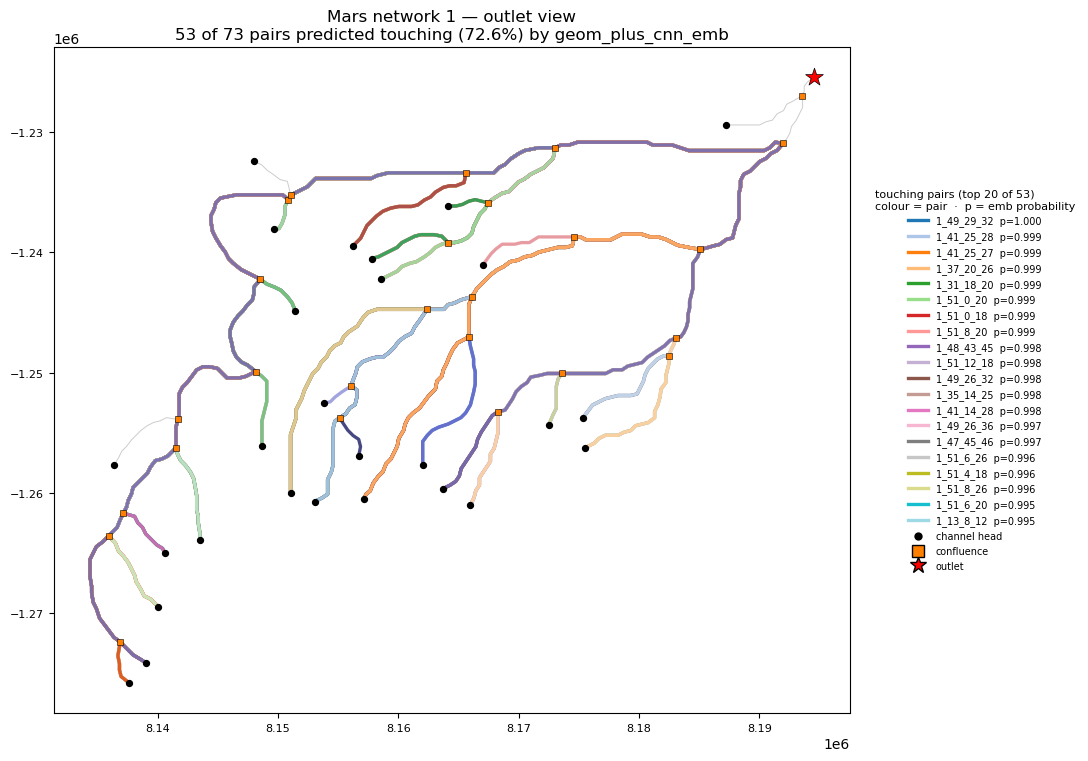

In [3]:
if have_data:
    fig = render_outlet_touching_pairs(
        nid,
        df[df["network_id"] == nid],
        segs_by_nid[nid],
        nodes_by_nid[nid],
        outlets_by_nid.get(nid),
        paths_lookup,
        output=None,  # inline, no file written
    )
else:
    fig = None
    print("Run: python scripts/rendering/render_mars_outlet_touching_pairs.py")
fig

---
Full run (writes one PNG per top network):

```bash
python scripts/rendering/render_mars_outlet_touching_pairs.py
```